# 02 — Preprocessing PRDECT-ID: Indonesian Emotion Classification

Dataset: [PRDECT-ID](https://www.kaggle.com/datasets/jocelyndumlao/prdect-id-indonesian-emotion-classification)

**Kolom yang digunakan:**
- Teks : `Customer Review`
- Label: `Emotion` → 5 nilai: `Happy`, `Love`, `Anger`, `Fear`, `Sadness`

**Label mapping (5-class emotion):**
- `happy`   → 0
- `love`    → 1
- `anger`   → 2
- `fear`    → 3
- `sadness` → 4

**Pipeline:**
1. Load dataset
2. EDA: distribusi label, panjang teks
3. Text cleaning (lowercase, hapus noise)
4. Stratified split (80% train / 20% test) — tanpa augmentasi
5. Export CSV

In [19]:
## 0. Google Colab Setup
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Google Colab detected — mounting Drive & installing packages ...")
    from google.colab import drive
    drive.mount("/content/drive")

    DRIVE_PROJECT = "/content/drive/MyDrive/xai_lime_vs_shap"

    if os.path.isdir(DRIVE_PROJECT):
        os.chdir(DRIVE_PROJECT)
        print(f"CWD set to: {DRIVE_PROJECT}")
    else:
        print(f"WARNING: '{DRIVE_PROJECT}' not found. Please check your Drive path.")

    !pip install -q kaggle
else:
    print("Local environment detected — skipping Colab setup.")

Google Colab detected — mounting Drive & installing packages ...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CWD set to: /content/drive/MyDrive/xai_lime_vs_shap


In [20]:
## 1. Imports & Config
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

def find_project_root() -> Path:
    markers = ["data", "notebooks", "src"]
    candidate = Path.cwd()
    for _ in range(3):
        if all((candidate / m).exists() for m in markers):
            return candidate
        candidate = candidate.parent
    return Path.cwd()

PROJECT_ROOT = find_project_root()
RAW_DIR     = PROJECT_ROOT / "data" / "raw"
PROC_DIR    = PROJECT_ROOT / "data" / "processed"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

# === FIX #1 & #2: Hard-code kolom yang benar berdasarkan struktur CSV aktual ===
# TEXT_COL : 'Customer Review'  (bukan 'Total Review' — auto-detect salah pilih!)
# LABEL_COL: 'Emotion'          (bukan 'Sentiment' — kita butuh 5-class emotion!)
TEXT_COL  = "Customer Review"
LABEL_COL = "Emotion"

print(f"Project root : {PROJECT_ROOT}")
print(f"Raw dir      : {RAW_DIR}")
print(f"Processed    : {PROC_DIR}")
print(f"TEXT_COL     : {TEXT_COL}")
print(f"LABEL_COL    : {LABEL_COL}")

Project root : /content/drive/MyDrive/xai_lime_vs_shap
Raw dir      : /content/drive/MyDrive/xai_lime_vs_shap/data/raw
Processed    : /content/drive/MyDrive/xai_lime_vs_shap/data/processed
TEXT_COL     : Customer Review
LABEL_COL    : Emotion


In [21]:
## 2. Download Dataset dari Kaggle (jika belum ada)
RAW_CSV = RAW_DIR / "PRDECT-ID Dataset.csv"

if not RAW_CSV.exists():
    print("Downloading PRDECT-ID dataset from Kaggle...")
    if IN_COLAB:
        !mkdir -p ~/.kaggle
        kaggle_json = Path("/content/drive/MyDrive/.kaggle/kaggle.json")
        if kaggle_json.exists():
            !cp {str(kaggle_json)} ~/.kaggle/kaggle.json
            !chmod 600 ~/.kaggle/kaggle.json
        os.chdir(str(RAW_DIR))
        !kaggle datasets download -d jocelyndumlao/prdect-id-indonesian-emotion-classification --unzip
        os.chdir(str(PROJECT_ROOT))
    else:
        print("Please download manually from:")
        print("https://www.kaggle.com/datasets/jocelyndumlao/prdect-id-indonesian-emotion-classification")
        print(f"Place the CSV in: {RAW_DIR}")
else:
    print(f"Dataset found: {RAW_CSV}")

Dataset found: /content/drive/MyDrive/xai_lime_vs_shap/data/raw/PRDECT-ID Dataset.csv


In [22]:
## 3. Load Dataset
csv_files    = list(RAW_DIR.glob("*.csv"))
prdect_files = [f for f in csv_files if "PRDECT" in f.name or "prdect" in f.name.lower()]

if not prdect_files:
    raise FileNotFoundError(f"PRDECT-ID CSV not found in {RAW_DIR}. Please download it first.")

RAW_CSV = prdect_files[0]
print(f"Loading: {RAW_CSV.name}")

df = pd.read_csv(RAW_CSV)
print(f"\nShape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nDtypes:\n{df.dtypes}")

Loading: PRDECT-ID Dataset.csv

Shape: (5400, 11)

Columns: ['Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 'Sentiment', 'Emotion']

Dtypes:
Category            object
Product Name        object
Location            object
Price                int64
Overall Rating     float64
Number Sold          int64
Total Review         int64
Customer Rating      int64
Customer Review     object
Sentiment           object
Emotion             object
dtype: object


In [23]:
## 4. Validasi Kolom
for col in [TEXT_COL, LABEL_COL]:
    assert col in df.columns, f"Kolom '{col}' tidak ditemukan! Kolom yang ada: {list(df.columns)}"

print("=== Sample Data ===")
display(df[[TEXT_COL, LABEL_COL]].head(5))

print(f"\nJenis data '{TEXT_COL}': {df[TEXT_COL].dtype}")
print(f"Contoh teks: {df[TEXT_COL].iloc[0]}")
print(f"\nJenis data '{LABEL_COL}': {df[LABEL_COL].dtype}")
print(f"Nilai unik '{LABEL_COL}': {sorted(df[LABEL_COL].dropna().unique())}")

=== Sample Data ===


,Customer Review,Emotion
0,Alhamdulillah berfungsi dengan baik. Packaging...,Happy
1,"barang bagus dan respon cepat, harga bersaing ...",Happy
2,"barang bagus, berfungsi dengan baik, seler ram...",Happy
3,bagus sesuai harapan penjual nya juga ramah. t...,Happy
4,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Happy



Jenis data 'Customer Review': object
Contoh teks: Alhamdulillah berfungsi dengan baik. Packaging aman. Respon cepat dan ramah. Seller dan kurir amanah

Jenis data 'Emotion': object
Nilai unik 'Emotion': ['Anger', 'Fear', 'Happy', 'Love', 'Sadness']


=== Distribusi Emosi ===
Emotion
Happy      1770
Sadness    1202
Fear        920
Love        809
Anger       699
Name: count, dtype: int64

Total: 5400 sampel


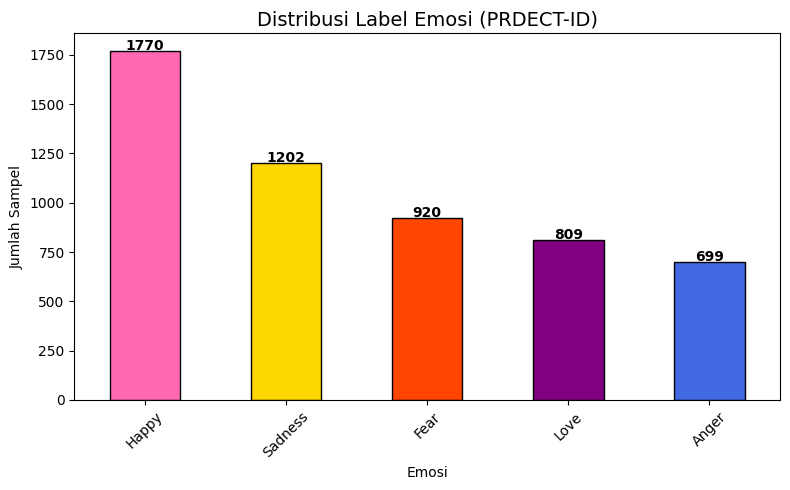

Plot saved.


In [24]:
## 5. EDA: Distribusi Label Emosi
print("=== Distribusi Emosi ===")
label_counts = df[LABEL_COL].value_counts()
print(label_counts)
print(f"\nTotal: {len(df)} sampel")

colors = ['#FF69B4', '#FFD700', '#FF4500', '#800080', '#4169E1']
fig, ax = plt.subplots(figsize=(8, 5))
label_counts.plot(kind='bar', ax=ax, color=colors[:len(label_counts)], edgecolor='black')
ax.set_title("Distribusi Label Emosi (PRDECT-ID)", fontsize=14)
ax.set_xlabel("Emosi")
ax.set_ylabel("Jumlah Sampel")
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(label_counts):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(PROC_DIR / "label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

=== Statistik Panjang Teks ===
       text_length  word_count
count      5400.00     5400.00
mean        103.81       16.10
std          98.26       15.65
min           3.00        1.00
25%          44.00        7.00
50%          78.00       12.00
75%         128.00       20.00
max        1058.00      184.00


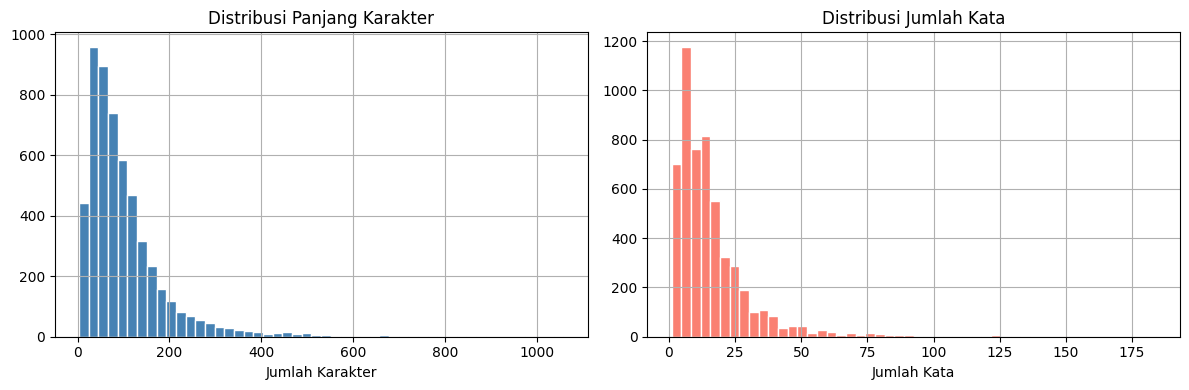

In [25]:
## 6. EDA: Statistik Panjang Teks
df['text_length'] = df[TEXT_COL].astype(str).apply(len)
df['word_count']  = df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))

print("=== Statistik Panjang Teks ===")
print(df[['text_length', 'word_count']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['text_length'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("Distribusi Panjang Karakter")
axes[0].set_xlabel("Jumlah Karakter")
df['word_count'].hist(bins=50, ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title("Distribusi Jumlah Kata")
axes[1].set_xlabel("Jumlah Kata")
plt.tight_layout()
plt.show()

In [26]:
## 7. Text Cleaning
def clean_text(text: str) -> str:
    """Basic text cleaning untuk Bahasa Indonesia:
    - Lowercase
    - Hapus URL
    - Hapus karakter non-alfanumerik (kecuali spasi)
    - Hapus spasi berlebih
    """
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Contoh cleaning
sample_text = df[TEXT_COL].iloc[0]
print(f"Original : {repr(sample_text)}")
print(f"Cleaned  : {repr(clean_text(sample_text))}")

Original : 'Alhamdulillah berfungsi dengan baik. Packaging aman. Respon cepat dan ramah. Seller dan kurir amanah'
Cleaned  : 'alhamdulillah berfungsi dengan baik packaging aman respon cepat dan ramah seller dan kurir amanah'


In [27]:
## 8. Apply Cleaning & Label Mapping

# === FIX #3: Label mapping disesuaikan dengan nilai AKTUAL di kolom 'Emotion' ===
# Nilai asli: 'Happy', 'Love', 'Anger', 'Fear', 'Sadness'
# Setelah .lower(): 'happy', 'love', 'anger', 'fear', 'sadness'
EMOTION_MAP = {
    'happy'  : 0,
    'love'   : 1,
    'anger'  : 2,
    'fear'   : 3,
    'sadness': 4,
}
ID2EMOTION = {v: k for k, v in EMOTION_MAP.items()}

# Normalize label (lowercase + strip)
df['emotion_label'] = df[LABEL_COL].str.lower().str.strip()

print("Nilai unik emotion_label:", sorted(df['emotion_label'].unique()))

# Apply mapping
df['label'] = df['emotion_label'].map(EMOTION_MAP)

# Cek NaN
n_unmapped = df['label'].isna().sum()
if n_unmapped > 0:
    print(f"WARNING: {n_unmapped} rows have unmapped labels:")
    print(df[df['label'].isna()]['emotion_label'].value_counts())
else:
    print("All labels mapped successfully!")

# Apply text cleaning
df['review_clean'] = df[TEXT_COL].apply(clean_text)

# Hapus baris kosong atau label NaN
before = len(df)
df = df.dropna(subset=['review_clean', 'label'])
df = df[df['review_clean'].str.strip().str.len() > 3]
after = len(df)
df['label'] = df['label'].astype(int)

print(f"\nData setelah cleaning: {before} → {after} ({before - after} dihapus)")
print(f"\nDistribusi final:")
print(df['emotion_label'].value_counts())

Nilai unik emotion_label: ['anger', 'fear', 'happy', 'love', 'sadness']
All labels mapped successfully!

Data setelah cleaning: 5400 → 5399 (1 dihapus)

Distribusi final:
emotion_label
happy      1770
sadness    1202
fear        920
love        808
anger       699
Name: count, dtype: int64


In [28]:
## 9. Stratified Split (80% Train / 20% Test) — No Augmentation
df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df['label']
)

print(f"Train size: {len(df_train)}")
print(f"Test size : {len(df_test)}")

print("\nDistribusi Train:")
print(df_train['emotion_label'].value_counts())

print("\nDistribusi Test:")
print(df_test['emotion_label'].value_counts())

Train size: 4319
Test size : 1080

Distribusi Train:
emotion_label
happy      1416
sadness     962
fear        736
love        646
anger       559
Name: count, dtype: int64

Distribusi Test:
emotion_label
happy      354
sadness    240
fear       184
love       162
anger      140
Name: count, dtype: int64


In [29]:
## 10. Export Data
import json

# Export cleaned full dataset
clean_out = PROC_DIR / "prdect_clean.csv"
df[['review_clean', 'emotion_label', 'label']].to_csv(clean_out, index=False)
print(f"Saved: {clean_out}")

# Export train/test split
train_out = PROC_DIR / "prdect_train.csv"
test_out  = PROC_DIR / "prdect_test.csv"
df_train[['review_clean', 'emotion_label', 'label']].to_csv(train_out, index=False)
df_test[['review_clean', 'emotion_label', 'label']].to_csv(test_out, index=False)
print(f"Saved: {train_out}")
print(f"Saved: {test_out}")

# Export label map
label_map_out = PROC_DIR / "prdect_label_map.json"
with open(label_map_out, 'w') as f:
    json.dump({"label2id": EMOTION_MAP, "id2label": ID2EMOTION}, f, indent=2)
print(f"Saved: {label_map_out}")

print("\n=== Summary ===")
print(f"Full dataset : {len(df)} rows")
print(f"Train set    : {len(df_train)} rows")
print(f"Test set     : {len(df_test)} rows")
print(f"Label mapping: {EMOTION_MAP}")

Saved: /content/drive/MyDrive/xai_lime_vs_shap/data/processed/prdect_clean.csv
Saved: /content/drive/MyDrive/xai_lime_vs_shap/data/processed/prdect_train.csv
Saved: /content/drive/MyDrive/xai_lime_vs_shap/data/processed/prdect_test.csv
Saved: /content/drive/MyDrive/xai_lime_vs_shap/data/processed/prdect_label_map.json

=== Summary ===
Full dataset : 5399 rows
Train set    : 4319 rows
Test set     : 1080 rows
Label mapping: {'happy': 0, 'love': 1, 'anger': 2, 'fear': 3, 'sadness': 4}
